<div>
<center>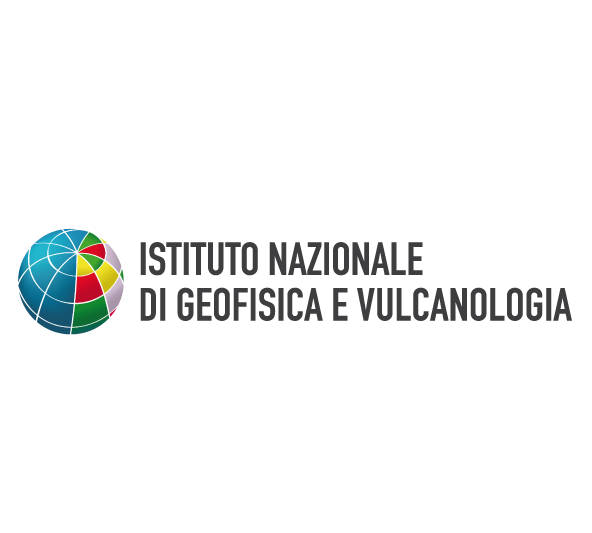</center>
</div>

__Sea Observations Utility for Reprocessing, Calibration and Evaluation  (SOURCE)__




*Authors*: Claudia Fratianni (claudia.fratianni@ingv.it), Simona Simoncelli (simona.simoncelli@ingv.it)
***
# Description

SOURCE permits to calibrate and validate ocean models within a selected spatial domain using *in-situ* observations. 
***
This notebook has been developed within the framework of FAIR-EASE project, a RIA project funded under HORIZON-INFRA-2021-EOSC-01-04.

In [ ]:
import sys,os,shutil,getpass
# the work dir must be in the root of "Source"
work_dir = os.getcwd()
if 'notebooks' in work_dir :
  parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

In [ ]:
import datetime
import numpy as np
import subprocess
import SOURCE
import folium
import random
import matplotlib.pyplot as plt


from urllib.parse import urlparse
from folium import plugins
from netCDF4 import Dataset,num2date
from shapely.geometry import box, Point, Polygon


## Observations module
***

This module is designed to prepare observation-based data through a pre-processing and re-processing operations. Data come from Near Real Time __moored__ __(MO)__ temperature and salinity observations distributed by Copernicus Marine Environment and Monitoring Service (__CMEMS__). Data are first pre-processed to match SOURCE format prerequisites by selecting the __space-time limits__, the __instruments__, the __variables__ and the __desired QFs__ to apply. The data are then re-processed by aggregating depth levels, removing duplicates and reordering record coordinate (time). Successively the data are quality controlled (QCed) maintaining the original sempling. The reprocessed and QCed data are saved and averaged by time. 

In the cell below you should provide following information:

1. the observation-based data path;
2. the __Essential Ocean Variables__ (EOVs) to be extract as NetCDF CF conventions __standard_name__ attributes;
3. Base working directory;
4. Output directory;
5. the parameter which selects the __QFs__ to apply (1 for *good data*, 1 and 2 for both *good* and *probably good* data);
6. Update mode execution switch (OPTIONAL);
7. Start date (OPTIONAL);
8. End date (OPTIONAL);
9. Latitude and Longitude limits;
10. Input CMEMS "instrument type" metadata filter space separated string (OPTIONAL);
11. Platform names CSV table;
12. verbosity switch (OPTIONAL)


#### 1. Define your time window

In [ ]:
targeted_range = '2016-01-01T00:00:00Z/2016-12-31T00:00:00Z' #set your own!

#### 2. Define in the `next cell` the input information:

In [ ]:
dataset_time_period='history'

# Processing mode
pr_mode='False' 
    
targeted_data_type = 'MO'
#targeted_data_type = 'ITINERIS'

input_directory=parent_dir+'/input_NA/'
output_directory=parent_dir+'/output_NA/'

# Observation base-data path
InDir=input_directory+'/OBSERVATION/'+targeted_data_type

# Essential Ocean Variables to be extract
InFields='sea_water_temperature sea_water_practical_salinity'

# Working directory
WorkDir=output_directory+'/OBSERVATION/output/work'

# Pre-processed directory
PreDir=output_directory+'/OBSERVATION/output/pre-processed'

# Output directory
OutDir=output_directory+'/OBSERVATION/output/statistic/'#output'

# History directory: in CREATION mode you have to create the reference history:
HisDir=output_directory+'/OBSERVATION/'

# Original DAC valid quality flags to use (space separated string, example: "0 1 2")
sel_QF='0 1 2'

# Start and end date

str_date=str(targeted_range.split('/')[0].split('T')[0].replace("-",""))
end_date=str(targeted_range.split('/')[1].split('T')[0].replace("-",""))

#Region longitude - latitude limits
Reg='-18.125 36.5 30 46'

#Iteration number
it_nu=3

# Temporal resolution
Temp_res='dm'

# Masking foreign seas switch for Mediterranean Sea processing 
msk_med='True'

#### 3. `Run the next cell` to pre-processing the observation based-data in the SOURCE internal netCDF format:

In [ ]:
SOURCE.obs_postpro.insitu_tac_pre_processing.insitu_tac_pre_processing(InDir,InFields,WorkDir,PreDir,sel_QF,pr_mode,str_date,end_date,Reg,True)

#### 4. `Run the next cell` to re-processing observational based-data to aggregate depth levels,remove duplicates and re-order record coordinate (time): 

In [ ]:
SOURCE.obs_postpro.obs_postpro.obs_postpro(PreDir,PreDir,InFields,WorkDir,OutDir,it_nu,'',str_date,end_date,Reg,msk_med)

#### 5. Add global attributes to the processed files

In [ ]:
StoringDirT = OutDir + Temp_res + '/' + 'sea_water_temperature/'
StoringDirS = OutDir + Temp_res + '/' + 'sea_water_practical_salinity/'

sorted_files_obsT = sorted([ x for x in os.listdir(StoringDirT) if x.endswith('temperature_dm.nc')])
sorted_files_obsS = sorted([ x for x in os.listdir(StoringDirS) if x.endswith('salinity_dm.nc')])

for f in sorted_files_obsT:
    print(f"** Reading File: {f}") 
    mooring = f.split('_')[1]
    print(f"Reading Platform: {mooring}") 
    with Dataset(StoringDirT + f, 'a') as obsT_nc:
        obsT_nc.setncattr('source', 'moored surface buoy')
        obsT_nc.delncattr('SOURCE_platform_code')
        obsT_nc.setncattr('SOURCE_institution', 'Istituto Nazionale di Geofisica e Vulcanologia - Bologna, Italy')
        obsT_nc.setncattr('SOURCE_platform_code', mooring)
        vartype_value = obsT_nc.getncattr('variable_type')
        obsT_nc.setncattr('SOURCE_variable_type', vartype_value)
        obsT_nc.delncattr('variable_type')
        hist_value = obsT_nc.getncattr('history')
        obsT_nc.delncattr('history') 
        obsT_nc.setncattr('history', hist_value)

for f in sorted_files_obsS:
    print(f"** Reading File: {f}") 
    mooring = f.split('_')[1]
    print(f"Reading Platform: {mooring}") 
    with Dataset(StoringDirS + f, 'a') as obsS_nc:
        obsS_nc.setncattr('source', 'moored surface buoy')
        obsS_nc.delncattr('SOURCE_platform_code')
        obsS_nc.setncattr('SOURCE_institution', 'Istituto Nazionale di Geofisica e Vulcanologia - Bologna, Italy')
        obsS_nc.setncattr('SOURCE_platform_code', mooring)
        vartype_value = obsS_nc.getncattr('variable_type')
        obsS_nc.setncattr('SOURCE_variable_type', vartype_value)
        obsS_nc.delncattr('variable_type')
        hist_value = obsS_nc.getncattr('history')
        obsS_nc.delncattr('history') 
        obsS_nc.setncattr('history', hist_value)